In [66]:
# ── Cell 1: Imports ────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [67]:
# ── Cell 2: Paths ──────────────────────────────────────────────
DATA_DIR  = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign'
TRAIN_DIR = os.path.join(DATA_DIR, 'Train')
TEST_DIR  = os.path.join(DATA_DIR, 'Test')

In [68]:
# ── Cell 3: Constants ──────────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_CLASSES = 43
EPOCHS      = 20
SEED        = 42

In [ ]:
# ── Cell 4: Load CSV + fix paths + split ───────────────────────
train_df = pd.read_csv(os.path.join(DATA_DIR, 'Train.csv'))

train_df['full_path'] = train_df['Path'].apply(
    lambda x: os.path.join(DATA_DIR, x)
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df['ClassId']
)

print(f"Train samples: {len(train_df)}")
print(f"Val samples:   {len(val_df)}")

In [82]:
# ── Cell 5: tf.data pipeline ───────────────────────────────────
def parse_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.resnet50.preprocess_input(img)
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

def augment(img, label):
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.rot90(img, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))
    img = tf.clip_by_value(img, -128.0, 128.0)
    return img, label

def make_dataset(df, augment_data=False):
    paths  = df['full_path'].values
    labels = df['ClassId'].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)

    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

In [83]:
# ── Cell 6: Create datasets ────────────────────────────────────
train_ds = make_dataset(train_df, augment_data=True)
val_ds   = make_dataset(val_df,   augment_data=False)

print(f"Train batches: {len(train_ds)}")
print(f"Val batches:   {len(val_ds)}")

Train batches: 981
Val batches:   246


In [84]:
# ── Cell 7: Verify one batch ───────────────────────────────────
for images, labels in train_ds.take(1):
    print(f"Batch image shape: {images.shape}")
    print(f"Batch label shape: {labels.shape}")
    print(f"Pixel range: [{images.numpy().min():.2f}, {images.numpy().max():.2f}]")

Batch image shape: (32, 224, 224, 3)
Batch label shape: (32, 43)
Pixel range: [-121.61, 128.00]


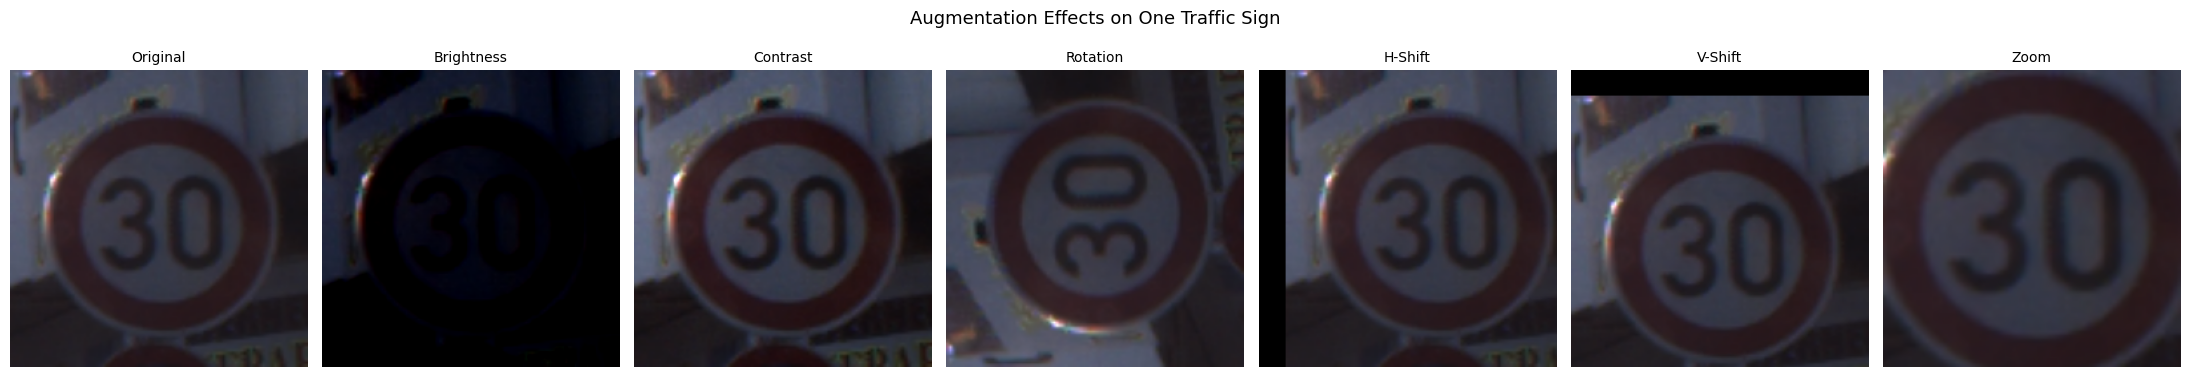

In [48]:
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
import os

# Load one sample image
sample_class = '1'
sample_path = os.path.join(TRAIN_DIR, sample_class)
sample_file = os.path.join(sample_path, os.listdir(sample_path)[0])

img = cv2.imread(sample_file)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))
img_tensor = tf.cast(img, tf.float32) / 255.0

def apply_augmentations(img_tensor):
    brightness = tf.image.random_brightness(img_tensor, 0.4)
    brightness = tf.clip_by_value(brightness, 0.0, 1.0)

    contrast = tf.image.random_contrast(img_tensor, 0.5, 1.5)
    contrast = tf.clip_by_value(contrast, 0.0, 1.0)

    rotation = tf.image.rot90(img_tensor, k=1)

    # Horizontal shift via padding + crop
    padded = tf.image.pad_to_bounding_box(img_tensor, 0, 20, 224, 244)
    h_shift = tf.image.crop_to_bounding_box(padded, 0, 0, 224, 224)

    # Vertical shift via padding + crop
    padded2 = tf.image.pad_to_bounding_box(img_tensor, 20, 0, 244, 224)
    v_shift = tf.image.crop_to_bounding_box(padded2, 0, 0, 224, 224)

    # Zoom via crop + resize
    crop = tf.image.central_crop(img_tensor, central_fraction=0.7)
    zoom = tf.image.resize(crop, [224, 224])

    return brightness, contrast, rotation, h_shift, v_shift, zoom

augmented = apply_augmentations(img_tensor)
titles = ['Original', 'Brightness', 'Contrast', 'Rotation', 'H-Shift', 'V-Shift', 'Zoom']
images = [img_tensor] + list(augmented)

fig, axes = plt.subplots(1, 7, figsize=(22, 4))
for ax, image, title in zip(axes, images, titles):
    ax.imshow(image.numpy())
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.suptitle('Augmentation Effects on One Traffic Sign', fontsize=13)
plt.tight_layout()
plt.show()

In [49]:
# Cell 8  — Build baseline CNN + summary
from tensorflow.keras import layers, models

def build_baseline_cnn(input_shape=(224, 224, 3), num_classes=43):

    model = models.Sequential([

        # ── Block 1 ────────────────────────────────
        layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # ── Block 2 ────────────────────────────────
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # ── Block 3 ────────────────────────────────
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # ── Head ───────────────────────────────────
        layers.GlobalAveragePooling2D(),
        layers.Dense(256),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,219 (539.92 KB)

 Trainable params: 137,771 (538.17 KB)

 Non-trainable params: 448 (1.75 KB)

In [50]:
#Cell 9  — Compile + train
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

baseline_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
  2/981 ━━━━━━━━━━━━━━━━━━━━ 1:11 73ms/step - accuracy: 0.0000e+00 - loss: 3.8367  

I0000 00:00:1783374775.894704     171 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.1203 - loss: 3.2650

2026-07-06 21:54:21.191555: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-06 21:54:21.334707: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


981/981 ━━━━━━━━━━━━━━━━━━━━ 120s 112ms/step - accuracy: 0.1479 - loss: 3.1046 - val_accuracy: 0.1965 - val_loss: 2.8076 - learning_rate: 0.0010
Epoch 2/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 64s 65ms/step - accuracy: 0.1896 - loss: 2.8460 - val_accuracy: 0.2418 - val_loss: 2.6291 - learning_rate: 0.0010
Epoch 3/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 64s 65ms/step - accuracy: 0.2176 - loss: 2.6989 - val_accuracy: 0.2626 - val_loss: 2.4959 - learning_rate: 0.0010
Epoch 4/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 64s 65ms/step - accuracy: 0.2391 - loss: 2.5966 - val_accuracy: 0.2158 - val_loss: 2.7705 - learning_rate: 0.0010
Epoch 5/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 64s 65ms/step - accuracy: 0.2567 - loss: 2.5280 - val_accuracy: 0.2881 - val_loss: 2.3448 - learning_rate: 0.0010
Epoch 6/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 64s 65ms/step - accuracy: 0.2745 - loss: 2.4518 - val_accuracy: 0.3298 - val_loss: 2.2212 - learning_rate: 0.0010
Epoch 7/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 64s 65ms/step - accuracy: 0.2898 - loss: 2.38

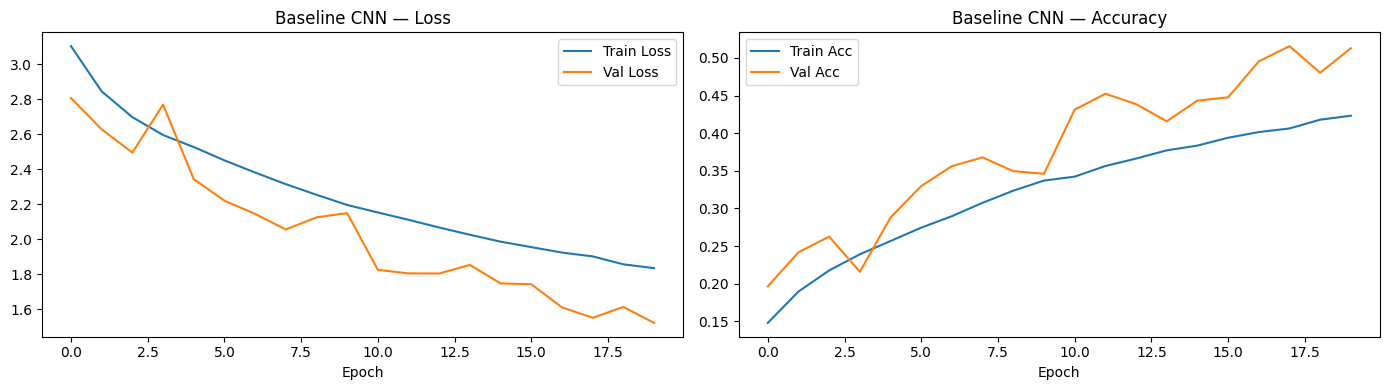

In [89]:
#Cell 10 — Plot results

def plot_history(history, title='Baseline CNN'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(history.history['accuracy'], label='Train Acc')
    axes[1].plot(history.history['val_accuracy'], label='Val Acc')
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history_baseline)

In [74]:
#  11 Loading Pretrained Weights
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, Input

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [75]:
 #Cell 12 — Freeze layers + verify

base_model.trainable = False

print(f"Total layers: {len(base_model.layers)}")
print(f"Trainable weights: {len(base_model.trainable_weights)}")
print(f"Non-trainable weights: {len(base_model.non_trainable_weights)}")

Total layers: 175
Trainable weights: 0
Non-trainable weights: 318


In [86]:
#13  Adding a Custom Classification Head
def build_resnet50(num_classes=43):
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False

    inputs = Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model, base_model

resnet_model, resnet_base = build_resnet50()
resnet_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,124,331 (92.03 MB)

 Trainable params: 536,107 (2.05 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

Epoch 1/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5473 - loss: 1.6049
Epoch 1: val_accuracy improved from None to 0.85680, saving model to resnet50_best.keras

Epoch 1: finished saving model to resnet50_best.keras
981/981 ━━━━━━━━━━━━━━━━━━━━ 127s 118ms/step - accuracy: 0.6624 - loss: 1.1129 - val_accuracy: 0.8568 - val_loss: 0.4718 - learning_rate: 0.0010
Epoch 2/20
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7853 - loss: 0.6375
Epoch 2: val_accuracy improved from 0.85680 to 0.88804, saving model to resnet50_best.keras

Epoch 2: finished saving model to resnet50_best.keras
981/981 ━━━━━━━━━━━━━━━━━━━━ 106s 108ms/step - accuracy: 0.8028 - loss: 0.5891 - val_accuracy: 0.8880 - val_loss: 0.3455 - learning_rate: 0.0010
Epoch 3/20
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8357 - loss: 0.4911
Epoch 3: val_accuracy improved from 0.88804 to 0.90895, saving model to resnet50_best.keras

Epoch 3: finished saving model to resnet50_best.keras
981/981 ━━━

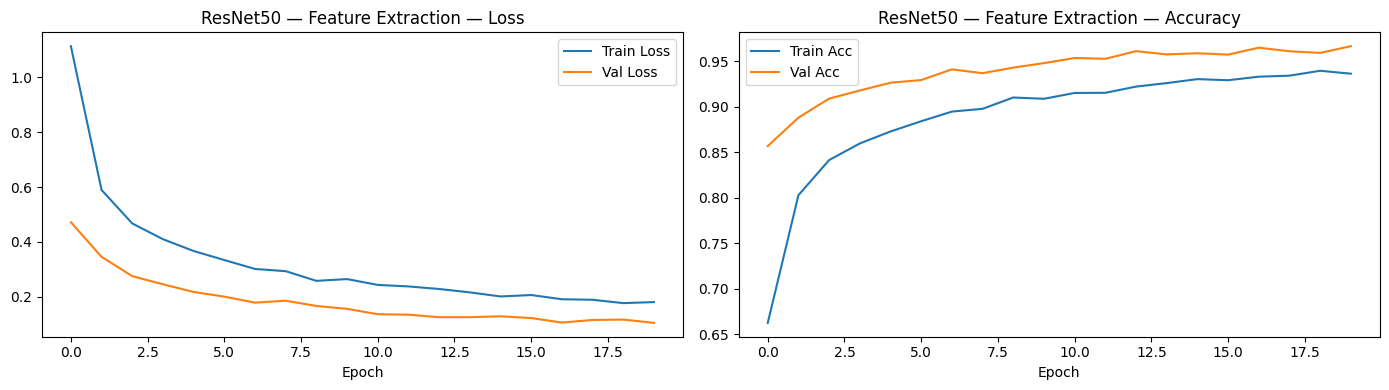

In [87]:
# Cell 14 — Compile + train
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

resnet_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('resnet50_best.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

EPOCHS = 20

history_resnet = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

plot_history(history_resnet, title='ResNet50 — Feature Extraction')

In [92]:
# Cell 15 — Evaluate on test set
# Load test CSV
test_df = pd.read_csv(os.path.join(DATA_DIR, 'Test.csv'))
test_df['full_path'] = test_df['Path'].apply(lambda x: os.path.join(DATA_DIR, x))

test_ds = make_dataset(test_df, augment_data=False)

loss, accuracy = resnet_model.evaluate(test_ds, verbose=1)
print(f"Test Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

395/395 ━━━━━━━━━━━━━━━━━━━━ 37s 93ms/step - accuracy: 0.8664 - loss: 0.5520
Test Loss:     0.5520
Test Accuracy: 0.8664 (86.64%)


In [91]:
for img, label in train_ds.take(1):
    print(f"Train batch - min: {img.numpy().min():.2f}, max: {img.numpy().max():.2f}, mean: {img.numpy().mean():.2f}")

for img, label in val_ds.take(1):
    print(f"Val batch   - min: {img.numpy().min():.2f}, max: {img.numpy().max():.2f}, mean: {img.numpy().mean():.2f}")

Train batch - min: -126.72, max: 128.00, mean: -40.96
Val batch   - min: -123.41, max: 151.06, mean: -28.52


Trainable layers: 22
Frozen layers:    153
Epoch 1/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.9856 - loss: 0.0431
Epoch 1: val_accuracy improved from None to 0.98750, saving model to resnet50_finetuned.keras

Epoch 1: finished saving model to resnet50_finetuned.keras
981/981 ━━━━━━━━━━━━━━━━━━━━ 167s 156ms/step - accuracy: 0.9864 - loss: 0.0425 - val_accuracy: 0.9875 - val_loss: 0.0365 - learning_rate: 1.0000e-05
Epoch 2/20
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.9859 - loss: 0.0415
Epoch 2: val_accuracy improved from 0.98750 to 0.98993, saving model to resnet50_finetuned.keras

Epoch 2: finished saving model to resnet50_finetuned.keras
981/981 ━━━━━━━━━━━━━━━━━━━━ 155s 158ms/step - accuracy: 0.9874 - loss: 0.0375 - val_accuracy: 0.9899 - val_loss: 0.0304 - learning_rate: 1.0000e-05
Epoch 3/20
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.9885 - loss: 0.0335
Epoch 3: val_accuracy improved from 0.98993 to 0.99056, saving model to resnet50_fin

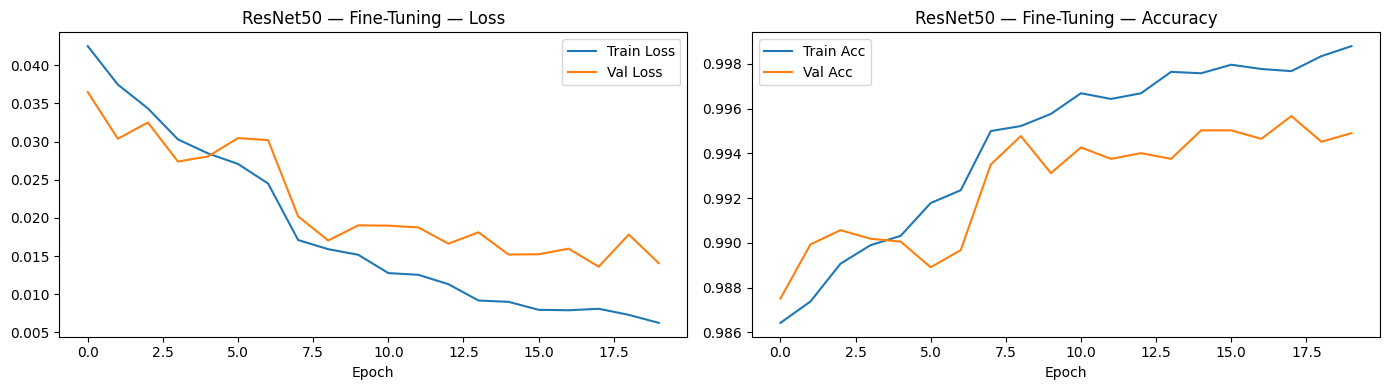

In [93]:
# ── Cell 16: Fine-tune ResNet50 ────────────────────────────────

# Unfreeze the base model
resnet_base.trainable = True

# Freeze all layers except the last conv block
for layer in resnet_base.layers[:143]:
    layer.trainable = False

# Keep all BatchNorm layers frozen
for layer in resnet_base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Verify
trainable = sum(1 for l in resnet_base.layers if l.trainable)
frozen = sum(1 for l in resnet_base.layers if not l.trainable)
print(f"Trainable layers: {trainable}")
print(f"Frozen layers:    {frozen}")

# Recompile with very low learning rate
resnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ft = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('resnet50_finetuned.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

history_resnet_ft = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_ft
)

plot_history(history_resnet_ft, title='ResNet50 — Fine-Tuning')

In [94]:
# ── Cell 17: Evaluate fine-tuned ResNet50 ──────────────────────
loss_ft, acc_ft = resnet_model.evaluate(test_ds, verbose=1)
print(f"Fine-tuned Test Loss:     {loss_ft:.4f}")
print(f"Fine-tuned Test Accuracy: {acc_ft:.4f} ({acc_ft*100:.2f}%)")

395/395 ━━━━━━━━━━━━━━━━━━━━ 36s 90ms/step - accuracy: 0.8887 - loss: 0.5244
Fine-tuned Test Loss:     0.5244
Fine-tuned Test Accuracy: 0.8887 (88.87%)


In [95]:
# ── Save both models ───────────────────────────────────────────
resnet_model.save('resnet50_finetuned_final.keras')
print("Saved.")

Saved.


In [ ]:
# ── Reload fine-tuned ResNet50  after cell 7 ─────────────────────────────────
resnet_model = tf.keras.models.load_model('resnet50_finetuned_final.keras')
print("Loaded successfully")